# Poland after EU accession

This notebook is a thin narrative view of the reproducible pipeline. The reusable implementation lives in `src/`, and generated tables and figures live in `reports/`. Run the pipeline from the repository root before opening this notebook. In PyCharm, select the **Poland EU Analysis (.venv)** kernel; do not use the WindowsApps Python alias.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

## Headline result

The generated executive summary intentionally separates the empirical result from causal interpretation.

In [2]:
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
display(Markdown((root / 'reports' / 'executive_summary.md').read_text(encoding='utf-8')))

# Executive summary

## Question

How did Poland's real GDP per capita evolve after its 2004 EU accession relative
to a weighted comparison of non-EU economies with similar pre-2004 trajectories?

## Result

Across 2004-2019, Poland's real GDP-per-capita growth index was on average
**-1.6%** relative to the synthetic comparison
(negative means below). In 2019 the gap was
**4.5%**. The post/pre RMSPE
ratio was **15.28**, ranking
**4 of 4** among the treated and
placebo countries whose pre-period RMSPE was no more than five times Poland's.
The descriptive placebo tail share was **1.000**.

The largest donor weight was MKD at
51.3%; the effective donor count was
2.8. Excluding one active donor at a time
produced mean post-period gaps from **-9.5% to 1.2%**.

## Interpretation

The fitted comparison does not provide unusual evidence that Poland's growth
path diverged after 2004: placebo countries produced at least as large a
post/pre fit deterioration. This is an informative negative result, not evidence
that accession had no effect. Accession was anticipated, reforms and capital
flows occurred simultaneously, and the pre-period contains only nine annual
observations.

## Data quality

The validated panel contains 1,400 country-indicator-year rows,
14 countries, and 4 indicators. The
overall missing-value share is 1.4%; donors
without complete primary-outcome coverage are excluded before estimation.

## Recommended next step

Use this result as a structured quantitative case study alongside historical
and institutional evidence. For a policy-grade evaluation, expand the
pre-treatment window, pre-register donor-selection rules, and test alternative
outcomes and comparison pools.


## Counterfactual trajectory

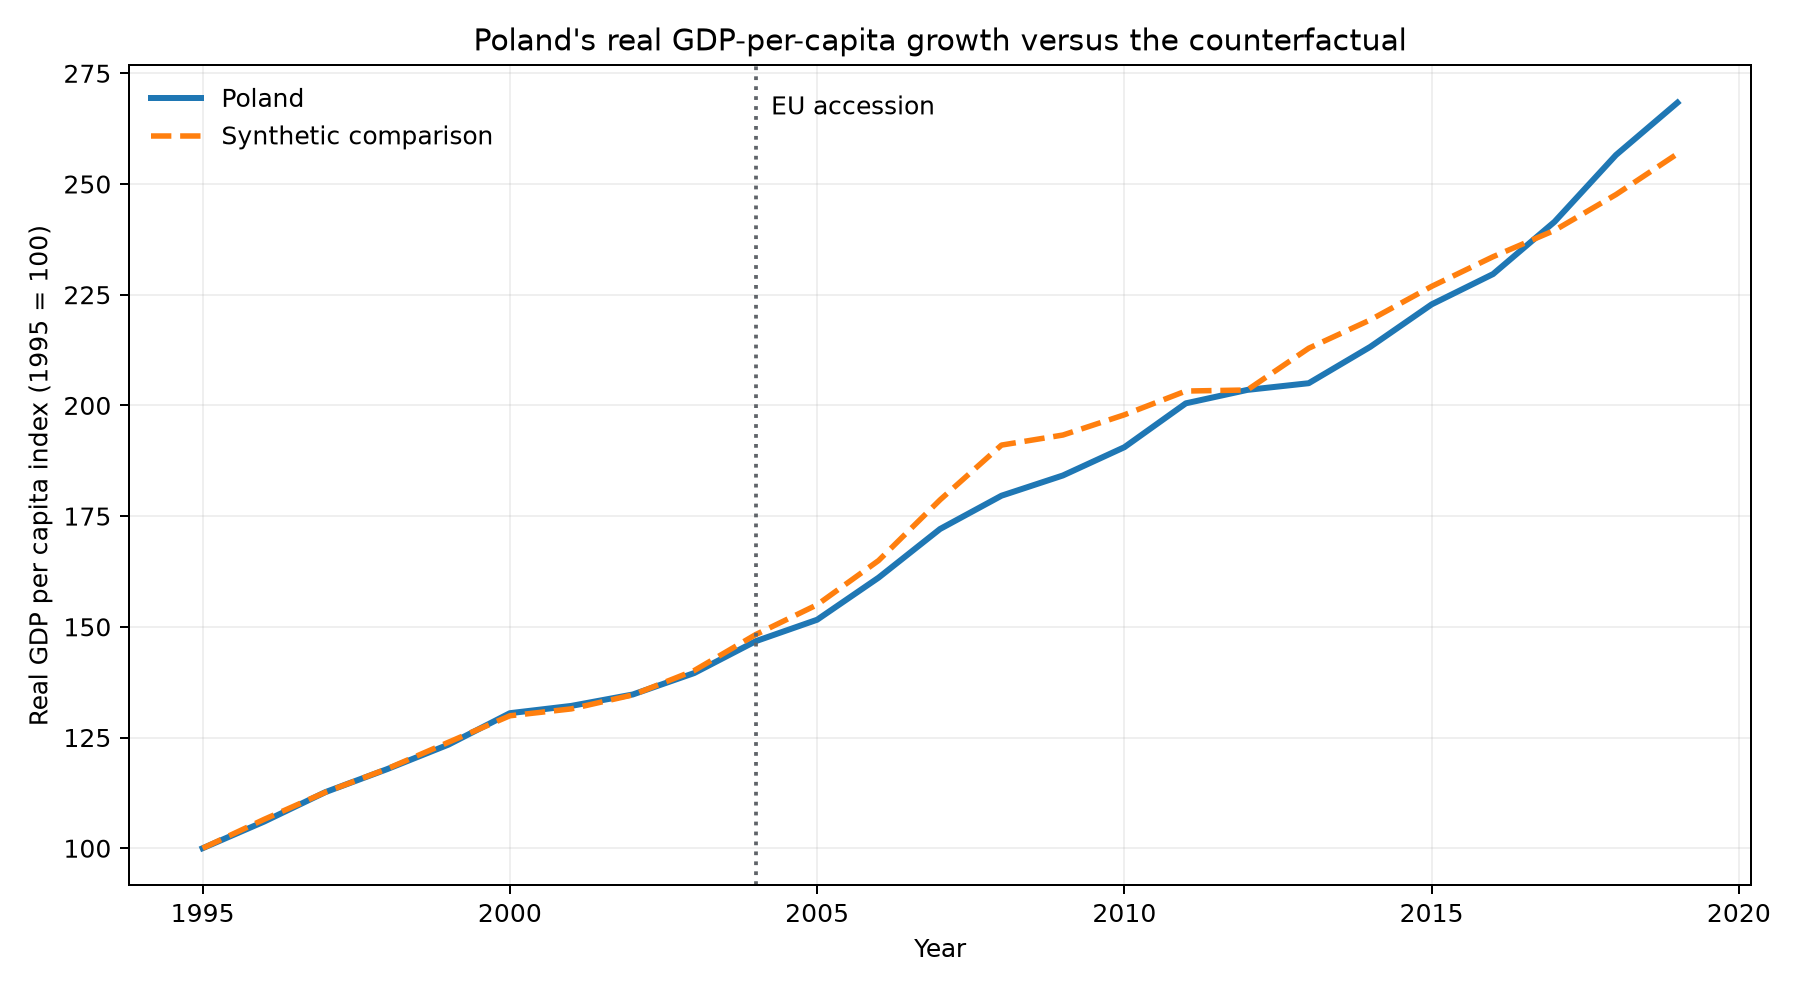

In [3]:
display(Image(filename=root / 'reports' / 'figures' / 'counterfactual.png'))

## Donor weights and placebo diagnostics

In [4]:
weights = pd.read_csv(root / 'reports' / 'tables' / 'donor_weights.csv')
placebos = pd.read_csv(root / 'reports' / 'tables' / 'placebo_diagnostics.csv')
display(weights.query('weight > 0.0001'))
display(placebos)

,country_code,weight
0,MKD,0.512619
1,KGZ,0.261649
2,ALB,0.110443
3,BIH,0.082232
4,AZE,0.033058


,country_code,pre_rmspe,post_rmspe,rmspe_ratio,is_treated
0,UZB,0.768682,51.572592,67.092198,False
1,AZE,2.728953,149.324244,54.718514,False
2,GEO,1.375333,45.638354,33.183505,False
3,KAZ,2.385820,72.736170,30.486870,False
4,ALB,4.599468,115.036755,25.010883,False
5,KGZ,1.560051,25.472929,16.328267,False
6,POL,0.431399,6.590560,15.277185,True
7,MKD,2.371710,35.960144,15.162118,False
8,ARM,4.594854,56.384513,12.271230,False
9,UKR,4.022229,44.733540,11.121581,False


## Interpretation guardrail

The divergence is evidence relative to the specified comparison design. It is not proof that EU membership alone caused the entire gap. See `reports/methodology.md` for the assumptions and sensitivity checks.